# Question Hierarchy Analysis

This notebook analyzes GSS survey questions to determine which questions are most "fundamental" - i.e., which questions are most predictive of or informative about other questions.

## Methods Compared

1. **Mutual Information**: Questions with high average MI with others are fundamental
2. **Predictive Power**: Questions that predict many others well (OOS) are fundamental
3. **Network Centrality**: Questions central in the correlation network are fundamental
4. **Dimensionality Reduction**: Questions loading on top PCs capture core variation
5. **Tree Structure (Chow-Liu)**: Questions near the root of the optimal tree are fundamental

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

In [2]:
# Import our methods
import sys
sys.path.insert(0, '.')

from methods.utils import load_and_preprocess, get_question_metadata
from methods.mutual_information import MutualInformationAnalyzer
from methods.predictive_power import PredictivePowerAnalyzer
from methods.network_centrality import NetworkCentralityAnalyzer
from methods.dimensionality import DimensionalityAnalyzer
from methods.tree_structure import TreeStructureAnalyzer

print("Methods imported successfully.")

Methods imported successfully.


## 1. Load and Preprocess Data

In [3]:
# Load data
df, question_cols = load_and_preprocess(
    'gss_2021-2024_public_opinion.csv',
    merge_duplicates=True,
    filter_valid_responses=True,
    min_valid_responses=100
)

print(f"Loaded {len(df)} respondents")
print(f"Number of questions: {len(question_cols)}")
print(f"\nQuestions: {question_cols}")

Loaded 11066 respondents
Number of questions: 138

Questions: ['polviews', 'natspac', 'natenvir', 'natheal', 'natcity', 'natcrime', 'natdrug', 'nateduc', 'natrace', 'natarms', 'nataid', 'natfare', 'natroad', 'natsoc', 'natmass', 'natpark', 'natsci', 'natenrgy', 'govchrst', 'goveqinc', 'goveqinc1', 'govfnaid', 'govfnanc', 'govunemp', 'govineq1', 'govineq2', 'ldctax', 'busgrn', 'carsgen', 'grncon', 'grnecon', 'grnexagg', 'grnprog', 'grnprice', 'grnsol', 'grntaxes', 'grwtharm', 'grwthelp', 'harmsgrn', 'ihlpgrn', 'impgrn', 'toodifme', 'othssame', 'conbus', 'conclerg', 'coneduc', 'confed', 'conjudge', 'conlegis', 'conarmy', 'confinan', 'consci', 'scienthe', 'spkath', 'colath', 'libath', 'spkcom', 'colcom', 'libcom', 'spkrac', 'colrac', 'librac', 'spkhomo', 'colhomo', 'libhomo', 'spkmslm', 'colmslm', 'libmslm', 'spkmil', 'colmil', 'libmil', 'spkathy', 'libathy', 'spkcomy', 'spkhomoy', 'spkmily', 'spkmslmy', 'spkracy', 'polhitok', 'polabuse', 'polmurdr', 'polescap', 'polattak', 'cappun', 'gun

In [4]:
# Check data availability per question
valid_counts = df[question_cols].notna().sum().sort_values(ascending=False)
print("Valid response counts per question:")
print(valid_counts.to_string())

Valid response counts per question:
nateduc       10978
natenvir      10929
natroad       10927
natheal       10911
natcrime      10891
natfare       10890
natarms       10840
natdrug       10827
natsoc        10812
nataid        10810
natenrgy      10800
polviews      10782
natchld       10778
discaff       10714
natsci        10713
natspac       10677
natrace       10595
natcity       10589
cappun         9609
gunlaw         8547
natpark        7781
natmass        7711
fehire         7356
marblk         7344
marwht         7334
marhisp        7331
marasian       7322
eqwlth         7316
confinan       7315
coneduc        7309
conarmy        7300
sexeduc        7297
wrkwayup       7287
conlegis       7284
spanking       7282
conjudge       7276
confed         7276
pillok         7271
conbus         7258
polescap       7252
helpsick       7245
polmurdr       7245
workwhts       7244
helppoor       7243
consci         7230
colath         7224
conclerg       7217
colrac         7215
colm

In [5]:
# CRITICAL: Analyze question availability by year
# This matters because pooling years assumes stable relationships across time

print("Question Availability Analysis by Year")
print("=" * 60)

# Check which questions have data in which years
years = sorted(df['year_label'].unique())
print(f"Years in data: {years}")

year_availability = {}
for col in question_cols:
    availability = []
    for year in years:
        year_data = df[df['year_label'] == year][col]
        valid_count = year_data.notna().sum()
        if valid_count > 50:  # Minimum threshold
            availability.append(int(year))
    year_availability[col] = availability

# Categorize questions
n_years = len(years)
questions_all_years = [q for q, yrs in year_availability.items() if len(yrs) == n_years]
questions_some_years = [q for q, yrs in year_availability.items() if 0 < len(yrs) < n_years]

print(f"\nQuestions in ALL {n_years} years: {len(questions_all_years)}")
print(f"Questions in SOME years only: {len(questions_some_years)}")

print(f"\n--- Questions in ALL years ({len(questions_all_years)}) ---")
print(questions_all_years)

print(f"\n--- Questions NOT in all years ({len(questions_some_years)}) ---")
for q in questions_some_years:
    print(f"  {q}: years {year_availability[q]}")

Question Availability Analysis by Year
Years in data: [np.int64(2021), np.int64(2022), np.int64(2024)]

Questions in ALL 3 years: 86
Questions in SOME years only: 52

--- Questions in ALL years (86) ---
['polviews', 'natspac', 'natenvir', 'natheal', 'natcity', 'natcrime', 'natdrug', 'nateduc', 'natrace', 'natarms', 'nataid', 'natfare', 'natroad', 'natsoc', 'natsci', 'natenrgy', 'conbus', 'conclerg', 'coneduc', 'confed', 'conjudge', 'conlegis', 'conarmy', 'confinan', 'consci', 'spkath', 'colath', 'libath', 'spkcom', 'colcom', 'libcom', 'spkrac', 'colrac', 'librac', 'spkmslm', 'colmslm', 'libmslm', 'spkathy', 'libathy', 'spkcomy', 'spkmslmy', 'spkracy', 'polhitok', 'polabuse', 'polmurdr', 'polescap', 'polattak', 'cappun', 'gunlaw', 'eqwlth', 'sexeduc', 'pillok', 'spanking', 'letdie1', 'getaheadnv', 'getaheadv', 'helpfulnv', 'helpfulv', 'helppoor', 'helpnot', 'helpsick', 'helpblk', 'racdif1', 'racdif2', 'racdif3', 'racdif4', 'wlthwhts', 'workwhts', 'discaff', 'affrmact', 'wrkwayup', 'fejo

In [6]:
# ANALYSIS STRATEGY SELECTION
# Choose one of the following approaches:

ANALYSIS_STRATEGY = "per_year"  # Options: "all_years_pooled", "common_questions_only", "per_year"

print("Available Analysis Strategies:")
print("-" * 60)
print("""
1. "all_years_pooled" (CURRENT):
   - Uses all respondents, pairwise complete cases
   - Pro: Maximum data
   - Con: Uneven comparisons, assumes stable relationships

2. "common_questions_only":
   - Only uses questions present in ALL years
   - Pro: Fair comparisons, stable across time
   - Con: Loses year-specific questions

3. "per_year":
   - Runs analysis separately for each year
   - Pro: Tests if fundamentalness is stable over time
   - Con: More complex, less data per analysis
""")
print(f"Selected strategy: {ANALYSIS_STRATEGY}")

# Apply the selected strategy
if ANALYSIS_STRATEGY == "common_questions_only":
    print(f"\nFiltering to {len(questions_all_years)} questions present in all years...")
    question_cols = questions_all_years
    print(f"Analysis will use: {question_cols}")
elif ANALYSIS_STRATEGY == "per_year":
    print("\nWill run analysis separately for each year (see Section 6 below)...")
else:
    print(f"\nUsing all {len(question_cols)} questions (pooled across years)...")
    print("NOTE: Be cautious about questions only in 1-2 years.")

Available Analysis Strategies:
------------------------------------------------------------

1. "all_years_pooled" (CURRENT):
   - Uses all respondents, pairwise complete cases
   - Pro: Maximum data
   - Con: Uneven comparisons, assumes stable relationships

2. "common_questions_only":
   - Only uses questions present in ALL years
   - Pro: Fair comparisons, stable across time
   - Con: Loses year-specific questions

3. "per_year":
   - Runs analysis separately for each year
   - Pro: Tests if fundamentalness is stable over time
   - Con: More complex, less data per analysis

Selected strategy: per_year

Will run analysis separately for each year (see Section 6 below)...


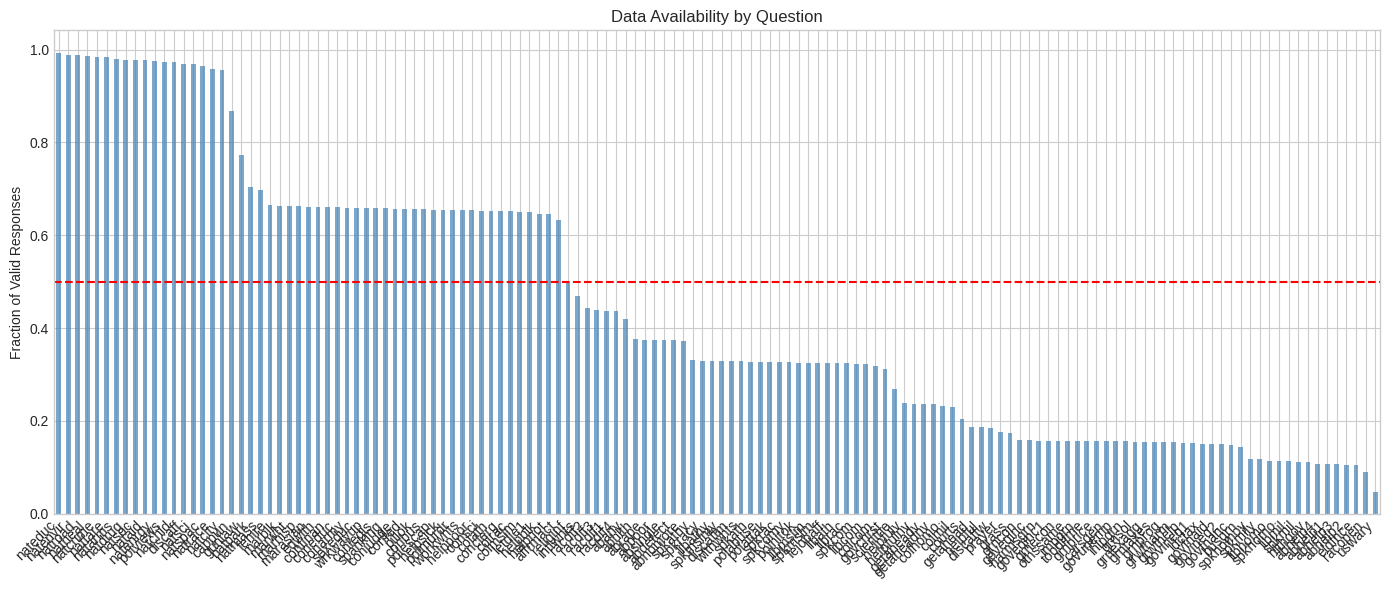

In [7]:
# Visualize missing data pattern
fig, ax = plt.subplots(figsize=(14, 6))
valid_frac = df[question_cols].notna().mean().sort_values(ascending=False)
valid_frac.plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
ax.set_ylabel('Fraction of Valid Responses')
ax.set_title('Data Availability by Question')
ax.axhline(y=0.5, color='red', linestyle='--', label='50% threshold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Run All Methods

In [8]:
# Store results from each method
results = {}

### 2.1 Mutual Information Analysis

In [9]:
%%time
mi_analyzer = MutualInformationAnalyzer(df, question_cols)
mi_analyzer.fit(verbose=True)
results['MI'] = mi_analyzer.get_scores()

Computing pairwise mutual information matrix (14 cores)...
  Computing 9453 pairs using 14 cores...
  Done!
Computing pairwise normalized MI matrix (14 cores)...
  Computing 9453 pairs using 14 cores...
  Done!
CPU times: user 2.31 s, sys: 520 ms, total: 2.83 s
Wall time: 32.6 s


In [10]:
print("Top 15 questions by Mutual Information:")
print(results['MI'][['avg_mi', 'avg_nmi', 'mi_breadth', 'entropy', 'composite_mi']].head(15).to_string())

Top 15 questions by Mutual Information:
             avg_mi   avg_nmi  mi_breadth   entropy  composite_mi
grnexagg   0.079165  0.059359          18  2.144713      0.965499
goveqinc1  0.066309  0.046807          10  2.284022      0.761720
polviews   0.066459  0.045036           7  2.510272      0.730126
helpblk    0.058630  0.042045          11  2.236805      0.726239
grnecon    0.066160  0.049107           8  2.168792      0.718554
eqwlth     0.061825  0.039668           7  2.591820      0.707148
goveqinc   0.062499  0.044594           7  2.255868      0.685483
govunemp   0.059868  0.043119           8  2.228059      0.683387
grntaxes   0.062828  0.045494           6  2.219292      0.668073
grncon     0.057160  0.044550           9  1.989846      0.664567
grnprice   0.060606  0.044617           7  2.133933      0.664117
helpnot    0.054820  0.039747           8  2.141266      0.644808
helpsick   0.051782  0.038962           9  2.028316      0.633569
grnprog    0.060346  0.046148       

In [11]:
# Most mutually informative pairs
print("\nTop 20 most mutually informative question pairs:")
print(mi_analyzer.get_top_pairs(20).to_string(index=False))


Top 20 most mutually informative question pairs:
question_1 question_2       mi      nmi
  marasian    marhisp 0.686442 0.651456
  marasian     marblk 0.640554 0.593622
    marblk    marhisp 0.630282 0.584261
  grnprice   grntaxes 0.583036 0.386230
    marwht     marblk 0.428985 0.403683
  marasian     marwht 0.424738 0.409763
  abnomore   absingle 0.414273 0.610397
    abpoor   absingle 0.413951 0.608416
    marwht    marhisp 0.405470 0.391300
  abnomore     abpoor 0.404357 0.597835
    grnsol   grntaxes 0.403501 0.264164
 goveqinc1     eqwlth 0.388480 0.229959
  absingle      abany 0.382720 0.561223
  grnprice     grnsol 0.378194 0.252768
  abnomore      abany 0.372072 0.549223
  goveqinc     eqwlth 0.355124 0.211063
   grnecon    grnprog 0.343570 0.233908
    abpoor      abany 0.338655 0.498697
   grnecon   grnexagg 0.332728 0.222696
 goveqinc1   govunemp 0.303989 0.194330


### 2.2 Predictive Power Analysis

In [ ]:
%%time
pred_analyzer = PredictivePowerAnalyzer(df, question_cols)
pred_analyzer.fit(min_samples=100, verbose=True)
results['Predictive'] = pred_analyzer.get_scores()

Computing predictive power matrix (18906 pairs) using 14 cores...


In [ ]:
print("Top 15 questions by Predictive Power:")
print(results['Predictive'][['avg_predictive_acc', 'avg_acc_over_baseline', 'avg_predictive_r2', 
                              'predictive_breadth', 'predictive_asymmetry', 'composite_predictive']].head(15).to_string())

In [ ]:
# Asymmetric predictions (potential causal direction)
print("\nTop predictive asymmetries (potential upstream -> downstream relationships):")
asymmetries = pred_analyzer.get_prediction_asymmetries()
print(asymmetries.head(20).to_string(index=False))

### 2.3 Network Centrality Analysis

In [ ]:
%%time
net_analyzer = NetworkCentralityAnalyzer(df, question_cols)
net_analyzer.fit(edge_threshold=0.1, verbose=True)
results['Network'] = net_analyzer.get_scores()

Computing correlation matrix using 14 cores...
  Computing 9453 pairs using 14 cores...


[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Batch computation too fast (0.04497933387756348s.) Setting batch_size=2.
[Parallel(n_jobs=14)]: Done   4 tasks      | elapsed:    0.1s
[Parallel(n_jobs=14)]: Done  13 tasks      | elapsed:    0.3s
[Parallel(n_jobs=14)]: Done  22 tasks      | elapsed:    0.6s
[Parallel(n_jobs=14)]: Done  38 tasks      | elapsed:    0.8s
[Parallel(n_jobs=14)]: Done  60 tasks      | elapsed:    1.1s
[Parallel(n_jobs=14)]: Done  86 tasks      | elapsed:    1.4s
[Parallel(n_jobs=14)]: Done 112 tasks      | elapsed:    1.7s
[Parallel(n_jobs=14)]: Done 142 tasks      | elapsed:    2.0s
[Parallel(n_jobs=14)]: Done 172 tasks      | elapsed:    2.4s
[Parallel(n_jobs=14)]: Done 206 tasks      | elapsed:    2.8s
[Parallel(n_jobs=14)]: Done 240 tasks      | elapsed:    3.2s
[Parallel(n_jobs=14)]: Done 278 tasks      | elapsed:    3.6s
[Parallel(n_jobs=14)]: Done 316 tasks      | elapsed:    4.1s
[Parallel(n_jobs=14)]

KeyboardInterrupt: 

In [ ]:
print("Top 15 questions by Network Centrality:")
print(results['Network'][['degree_centrality', 'strength', 'betweenness_centrality', 
                           'eigenvector_centrality', 'pagerank', 'composite_centrality']].head(15).to_string())

In [ ]:
# Network statistics
print("\nNetwork Statistics:")
for k, v in net_analyzer.get_network_stats().items():
    print(f"  {k}: {v}")

In [ ]:
# Community detection
communities = net_analyzer.get_communities()
comm_df = pd.DataFrame({'question': list(communities.keys()), 'community': list(communities.values())})
print(f"\nDetected {comm_df['community'].nunique()} communities:")
for comm_id in sorted(comm_df['community'].unique()):
    members = comm_df[comm_df['community'] == comm_id]['question'].tolist()
    print(f"  Community {comm_id}: {members}")

### 2.4 Dimensionality Reduction Analysis

In [ ]:
%%time
dim_analyzer = DimensionalityAnalyzer(df, question_cols)
dim_analyzer.fit(n_components=10, min_valid_frac=0.2, verbose=True)
results['Dimensionality'] = dim_analyzer.get_scores()

In [ ]:
print("Top 15 questions by Dimensionality (PCA loadings):")
cols_to_show = ['pc1_loading', 'total_variance_pca', 'max_loading_pca', 'composite_dimensionality']
if 'communality' in results['Dimensionality'].columns:
    cols_to_show.insert(-1, 'communality')
print(results['Dimensionality'][cols_to_show].head(15).to_string())

In [ ]:
# Variance explained
var_explained = dim_analyzer.get_variance_explained()
print("\nVariance Explained by Principal Components:")
print(var_explained.head(10).to_string(index=False))

In [ ]:
# Interpret top components
print("\nTop Principal Components Interpretation:")
interp = dim_analyzer.interpret_components(n_components=5, n_vars=5)
for comp, data in interp.items():
    print(f"\n{comp} ({data['variance_explained']:.1%} variance):")
    print(f"  Positive: {[f'{v}({l:.2f})' for v, l in data['positive'][:3]]}")
    print(f"  Negative: {[f'{v}({l:.2f})' for v, l in data['negative'][:3]]}")

### 2.5 Tree Structure Analysis (Chow-Liu)

In [ ]:
%%time
tree_analyzer = TreeStructureAnalyzer(df, question_cols)
tree_analyzer.fit(min_samples=50, verbose=True)
results['Tree'] = tree_analyzer.get_scores()

In [ ]:
print("Top 15 questions by Tree Structure:")
print(results['Tree'][['tree_depth', 'subtree_size', 'tree_betweenness', 
                        'hierarchy_centrality', 'composite_tree']].head(15).to_string())

In [ ]:
# Tree structure
print(f"\nChow-Liu Tree Root: {tree_analyzer.tree_root}")
print("\nTop tree edges (strongest dependencies):")
print(tree_analyzer.get_tree_edges().head(15).to_string(index=False))

## 3. Compare Methods

In [ ]:
# Combine composite scores from all methods
composite_scores = pd.DataFrame(index=question_cols)

composite_scores['MI'] = results['MI']['composite_mi']
composite_scores['Predictive'] = results['Predictive']['composite_predictive']
composite_scores['Network'] = results['Network']['composite_centrality']
composite_scores['Dimensionality'] = results['Dimensionality']['composite_dimensionality']
composite_scores['Tree'] = results['Tree']['composite_tree']

# Fill NaN with 0 for ranking purposes
composite_scores = composite_scores.fillna(0)

# Compute average rank
ranks = composite_scores.rank(ascending=False)
composite_scores['avg_rank'] = ranks.mean(axis=1)
composite_scores['rank_std'] = ranks.std(axis=1)

# Ensemble score (mean of normalized scores)
normalized = composite_scores[['MI', 'Predictive', 'Network', 'Dimensionality', 'Tree']].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() > x.min() else 0
)
composite_scores['ensemble_score'] = normalized.mean(axis=1)

composite_scores = composite_scores.sort_values('ensemble_score', ascending=False)
print("Combined Rankings (sorted by ensemble score):")
print(composite_scores.round(3).to_string())

In [ ]:
# Correlation between methods
method_corr = composite_scores[['MI', 'Predictive', 'Network', 'Dimensionality', 'Tree']].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(method_corr, annot=True, cmap='RdYlBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Spearman Correlation Between Methods')
plt.tight_layout()
plt.show()

print("\nMethod Agreement (Spearman correlations):")
print(method_corr.round(3).to_string())

In [ ]:
# Visualize rankings across methods
fig, ax = plt.subplots(figsize=(14, 8))

# Get top 20 questions by ensemble score
top_questions = composite_scores.head(20).index.tolist()

# Create rank matrix for heatmap
rank_matrix = ranks.loc[top_questions, ['MI', 'Predictive', 'Network', 'Dimensionality', 'Tree']]

sns.heatmap(rank_matrix, annot=True, fmt='.0f', cmap='YlOrRd_r', ax=ax)
ax.set_title('Question Rankings Across Methods (Top 20 by Ensemble)\n(Lower = More Fundamental)')
ax.set_xlabel('Method')
ax.set_ylabel('Question')
plt.tight_layout()
plt.show()

In [ ]:
# Questions with high agreement vs disagreement
print("Questions with HIGHEST agreement across methods (low rank std):")
print(composite_scores.nsmallest(10, 'rank_std')[['avg_rank', 'rank_std', 'ensemble_score']].to_string())

print("\nQuestions with LOWEST agreement across methods (high rank std):")
print(composite_scores.nlargest(10, 'rank_std')[['avg_rank', 'rank_std', 'ensemble_score']].to_string())

## 4. Final Hierarchy

In [ ]:
# Create final hierarchy based on ensemble score
final_hierarchy = composite_scores[['ensemble_score', 'avg_rank', 'rank_std']].copy()
final_hierarchy['tier'] = pd.cut(
    final_hierarchy['ensemble_score'],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=['Tier 4 (Specific)', 'Tier 3', 'Tier 2', 'Tier 1 (Fundamental)']
)

# Add topic metadata
metadata = get_question_metadata(question_cols)
final_hierarchy = final_hierarchy.join(metadata.set_index('variable'))

print("Final Question Hierarchy:")
print("=" * 80)
for tier in ['Tier 1 (Fundamental)', 'Tier 2', 'Tier 3', 'Tier 4 (Specific)']:
    tier_qs = final_hierarchy[final_hierarchy['tier'] == tier]
    if len(tier_qs) > 0:
        print(f"\n{tier}:")
        for q in tier_qs.index:
            topic = tier_qs.loc[q, 'topic']
            score = tier_qs.loc[q, 'ensemble_score']
            print(f"  {q:15s} [{topic:20s}] (score: {score:.3f})")

In [ ]:
# Visualize final hierarchy
fig, ax = plt.subplots(figsize=(12, 8))

# Sort by ensemble score
plot_data = final_hierarchy.sort_values('ensemble_score', ascending=True)

# Color by tier
tier_colors = {
    'Tier 1 (Fundamental)': '#d62728',
    'Tier 2': '#ff7f0e', 
    'Tier 3': '#2ca02c',
    'Tier 4 (Specific)': '#1f77b4'
}
colors = [tier_colors.get(t, 'gray') for t in plot_data['tier']]

bars = ax.barh(range(len(plot_data)), plot_data['ensemble_score'], color=colors, alpha=0.8)
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data.index, fontsize=8)
ax.set_xlabel('Ensemble Fundamentalness Score')
ax.set_title('Question Hierarchy (Higher = More Fundamental)')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in tier_colors.items()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
# Save results
final_hierarchy.to_csv('question_hierarchy_results.csv')
composite_scores.to_csv('question_hierarchy_all_scores.csv')

print("Results saved to:")
print("  - question_hierarchy_results.csv")
print("  - question_hierarchy_all_scores.csv")

## 5. Method Evaluation: Which Method is Most Trustworthy?

To help decide which method is most trustworthy, we evaluate several criteria:

In [ ]:
# Criterion 1: Agreement with other methods
# Methods that agree with others are more likely to capture something real
agreement_scores = method_corr.mean()
print("Criterion 1: Average Agreement with Other Methods")
print(agreement_scores.sort_values(ascending=False).to_string())

In [ ]:
# Criterion 2: Face validity - do the top questions make intuitive sense?
# (This requires manual inspection)
print("\nCriterion 2: Top 5 Questions per Method (for face validity check):")
for method in ['MI', 'Predictive', 'Network', 'Dimensionality', 'Tree']:
    top5 = composite_scores[method].nlargest(5).index.tolist()
    print(f"  {method:15s}: {top5}")

## 6. Per-Year Analysis (Stability Check)

If `ANALYSIS_STRATEGY == "per_year"`, this section runs the analysis separately for each year to test whether "fundamentalness" is stable over time.

In [ ]:
# Per-Year Analysis: Run MI analysis for each year separately
# This tests whether the "fundamentalness" rankings are stable over time

if ANALYSIS_STRATEGY == "per_year" or True:  # Always run for comparison
    print("Running Per-Year Mutual Information Analysis...")
    print("=" * 60)
    
    per_year_scores = {}
    
    for year in years:
        print(f"\n--- Year {year} ---")
        year_df = df[df['year_label'] == year].copy()
        
        # Get questions available this year
        year_questions = [q for q in question_cols if year_df[q].notna().sum() > 50]
        print(f"  Questions available: {len(year_questions)}")
        print(f"  Respondents: {len(year_df)}")
        
        if len(year_questions) < 5:
            print("  Skipping - too few questions")
            continue
        
        # Run MI analysis for this year
        year_mi = MutualInformationAnalyzer(year_df, year_questions)
        year_mi.fit(verbose=False)
        year_scores = year_mi.get_scores()['composite_mi']
        
        per_year_scores[year] = year_scores
        
        print(f"  Top 5 fundamental questions: {year_scores.nlargest(5).index.tolist()}")
    
    # Compare rankings across years (for common questions)
    if len(per_year_scores) > 1:
        print("\n" + "=" * 60)
        print("CROSS-YEAR STABILITY ANALYSIS")
        print("=" * 60)
        
        # Find questions in all years
        common_qs = set(per_year_scores[years[0]].index)
        for year in years[1:]:
            if year in per_year_scores:
                common_qs &= set(per_year_scores[year].index)
        common_qs = list(common_qs)
        
        print(f"\nQuestions present in all years: {len(common_qs)}")
        
        if len(common_qs) > 5:
            # Create comparison dataframe
            year_comparison = pd.DataFrame(index=common_qs)
            for year in years:
                if year in per_year_scores:
                    year_comparison[f'MI_{year}'] = per_year_scores[year].reindex(common_qs)
            
            # Compute cross-year correlations
            print("\nSpearman correlation of MI scores across years:")
            year_corr = year_comparison.corr(method='spearman')
            print(year_corr.round(3).to_string())
            
            # Identify stable vs unstable questions
            year_comparison['mean_score'] = year_comparison.mean(axis=1)
            year_comparison['std_score'] = year_comparison.std(axis=1)
            year_comparison['cv'] = year_comparison['std_score'] / (year_comparison['mean_score'] + 0.001)
            
            print("\nMost STABLE questions (low coefficient of variation):")
            stable = year_comparison.nsmallest(10, 'cv')[['mean_score', 'std_score', 'cv']]
            print(stable.to_string())
            
            print("\nMost UNSTABLE questions (high coefficient of variation):")
            unstable = year_comparison.nlargest(10, 'cv')[['mean_score', 'std_score', 'cv']]
            print(unstable.to_string())

Running Per-Year Mutual Information Analysis...

--- Year 2021 ---
  Questions available: 124
  Respondents: 3886
  Top 5 fundamental questions: ['grnexagg', 'polviews', 'helpblk', 'eqwlth', 'goveqinc1']

--- Year 2022 ---
  Questions available: 104
  Respondents: 3995
  Top 5 fundamental questions: ['abnomore', 'helpblk', 'abpoor', 'polviews', 'absingle']

--- Year 2024 ---
  Questions available: 94
  Respondents: 3185
  Top 5 fundamental questions: ['helpblk', 'polviews', 'eqwlth', 'helppoor', 'wrkwayup']

CROSS-YEAR STABILITY ANALYSIS

Questions present in all years: 86

Spearman correlation of MI scores across years:
         MI_2021  MI_2022  MI_2024
MI_2021    1.000    0.905     0.90
MI_2022    0.905    1.000     0.95
MI_2024    0.900    0.950     1.00

Most STABLE questions (low coefficient of variation):
          mean_score  std_score        cv
natarms     0.386312   0.003815  0.009849
helpblk     0.836656   0.014253  0.017015
consci      0.332401   0.006002  0.018004
wrkwayup

In [ ]:
# Criterion 3: Stability - how consistent are rankings within the method?
# We can use bootstrap resampling to check this
print("\nCriterion 3: Method Stability Analysis")
print("(Spearman correlation between bootstrap samples - higher = more stable)")

# For MI method, we can check consistency
# This would require rerunning on bootstrap samples - simplified version:
print("\nNote: Full stability analysis requires bootstrap resampling.")
print("Consider running each method on different subsets of the data.")


Criterion 3: Method Stability Analysis
(Spearman correlation between bootstrap samples - higher = more stable)

Note: Full stability analysis requires bootstrap resampling.
Consider running each method on different subsets of the data.


In [ ]:
# Summary recommendation
print("\n" + "=" * 80)
print("SUMMARY: Method Evaluation")
print("=" * 80)
print("""
Based on the analysis:

1. MUTUAL INFORMATION:
   + Theoretically grounded in information theory
   + Symmetric measure (no direction assumed)
   + Captures non-linear relationships
   - Requires discretization for continuous variables

2. PREDICTIVE POWER:
   + Directly measures what we care about (prediction)
   + Asymmetric - can suggest causal direction
   + Uses out-of-sample validation (less overfitting)
   - Computationally expensive
   - Results depend on model choice

3. NETWORK CENTRALITY:
   + Captures global structure
   + Multiple centrality measures provide robustness
   + Intuitive graph interpretation
   - Threshold choice affects results
   - Doesn't distinguish direction

4. DIMENSIONALITY REDUCTION (PCA):
   + Well-understood mathematically
   + Finds major dimensions of variation
   + Fast and stable
   - Assumes linear relationships
   - Sensitive to missing data imputation

5. TREE STRUCTURE (Chow-Liu):
   + Optimal tree approximation to joint distribution
   + Natural hierarchy interpretation
   + Sparse (easy to interpret)
   - Tree structure may be too restrictive
   - Root choice is somewhat arbitrary

RECOMMENDATION:
Use the ENSEMBLE SCORE as the primary ranking, which averages across all methods.
Questions ranked high by MULTIPLE methods are most likely truly fundamental.
Pay special attention to questions with LOW rank_std (high agreement).
""")


SUMMARY: Method Evaluation

Based on the analysis:

1. MUTUAL INFORMATION:
   + Theoretically grounded in information theory
   + Symmetric measure (no direction assumed)
   + Captures non-linear relationships
   - Requires discretization for continuous variables

2. PREDICTIVE POWER:
   + Directly measures what we care about (prediction)
   + Asymmetric - can suggest causal direction
   + Uses out-of-sample validation (less overfitting)
   - Computationally expensive
   - Results depend on model choice

3. NETWORK CENTRALITY:
   + Captures global structure
   + Multiple centrality measures provide robustness
   + Intuitive graph interpretation
   - Threshold choice affects results
   - Doesn't distinguish direction

4. DIMENSIONALITY REDUCTION (PCA):
   + Well-understood mathematically
   + Finds major dimensions of variation
   + Fast and stable
   - Assumes linear relationships
   - Sensitive to missing data imputation

5. TREE STRUCTURE (Chow-Liu):
   + Optimal tree approximation 